Load raw CSV
↓
Clean target
↓
Sample data
↓
Select features
↓
One-hot encode
↓
Add record_id + event_time
↓
Create SageMaker Feature Store
↓
Ingest features
↓
Split into train/val/test/production
↓
Train models

In [1]:
# -----------------------------
# 1. Import libraries
# -----------------------------

import os
import json
import joblib
import boto3
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

from xgboost import XGBClassifier

In [2]:
# -----------------------------
# 2
# -----------------------------
import sagemaker
from sagemaker.core.helper.session_helper import Session

session = Session()

print(session.default_bucket())

sagemaker.config INFO - Not applying SDK defaults from location: /etc/xdg/sagemaker/config.yaml


sagemaker.config INFO - Not applying SDK defaults from location: /home/sagemaker-user/.config/sagemaker/config.yaml


sagemaker-us-east-1-646180330281


In [ ]:
# ============================================================
# 3. Project Configuration
# ============================================================
# Philosophy:
#
#
# These variables define:
#
# - AWS resources used throughout the project
# - Dataset location and file names
# - Sampling parameters to control costs
# - Reproducibility settings for experiments
# - The target variable to be predicted
#
# By storing configuration values in one place,
# we avoid hardcoding them throughout the notebook
# and simplify future updates.
# ============================================================

# BUCKET_NAME = session.default_bucket()
BUCKET_NAME = "aai540-diabetes-readmission-ali-2026" # replace with your bucket name
REGION = "us-east-1" # replace with your region

# if you are in a new region you can try this code! and make the above line commented out
# REGION = boto3.Session().region_name 
RAW_FILE = "diabetic_data.csv"

# Use a smaller sample to reduce SageMaker
# training time and AWS costs
SAMPLE_SIZE = 15000

# Random seed for reproducible results
RANDOM_STATE = 42

# Target variable for prediction
TARGET = "readmitted"

# Create an Amazon S3 client for interacting
# with objects stored in the data lake
s3 = boto3.client("s3", region_name=REGION)

In [14]:
# -----------------------------
# 4. Load raw dataset
# -----------------------------

df = pd.read_csv(RAW_FILE)

print("Original shape:", df.shape)
print(df[TARGET].value_counts())
df.head()

Original shape: (101766, 50)
readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [15]:
# ============================================================
# 5. Exploratory Data Analysis (EDA)
# ============================================================
# Philosophy:
#
# Before building any machine learning system,
# we should understand the dataset.
#
# EDA helps answer:
#
# - How many records exist?
# - How many features exist?
# - Which columns contain missing values?
# - Is the target balanced?
# - Are there obvious data quality issues?
# ============================================================

print("Dataset Shape:")
print(df.shape)

print("\nTop Missing Value Columns:")
print(
    df.isnull()
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

print("\nOriginal Readmission Distribution:")
print(
    df["readmitted"]
      .value_counts(normalize=True)
)

Dataset Shape:
(101766, 50)

Top Missing Value Columns:
max_glu_serum               96420
A1Cresult                   84748
race                            0
gender                          0
age                             0
weight                          0
admission_type_id               0
discharge_disposition_id        0
admission_source_id             0
time_in_hospital                0
dtype: int64

Original Readmission Distribution:
readmitted
NO     0.539119
>30    0.349282
<30    0.111599
Name: proportion, dtype: float64


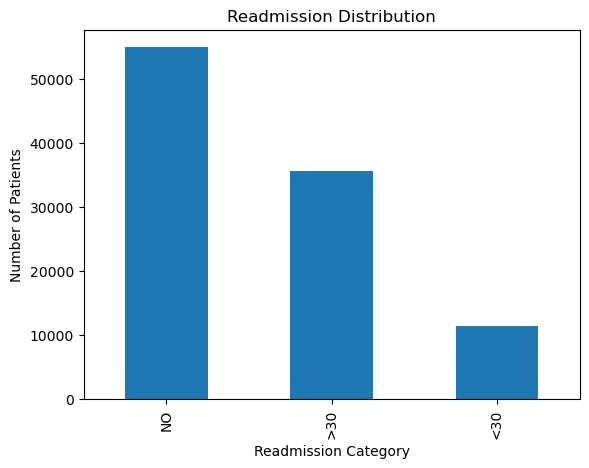

In [16]:
# ============================================================
# 6. Target Distribution Visualization
# ============================================================
# Philosophy:
#
# Understanding the target variable is one of the
# most important steps before training a model.
#
# This visualization helps us:
#
# - Identify class imbalance
# - Understand the frequency of readmission outcomes
# - Determine whether re-sampling techniques may
#   be needed later
# - Verify that the target data was loaded correctly
#
# In this dataset:
# - NO   = No readmission
# - >30  = Readmitted after 30 days
# - <30  = Readmitted within 30 days
# ============================================================

import matplotlib.pyplot as plt

df["readmitted"].value_counts().plot(
    kind="bar"
)

plt.title("Readmission Distribution")
plt.xlabel("Readmission Category")
plt.ylabel("Number of Patients")
plt.show()

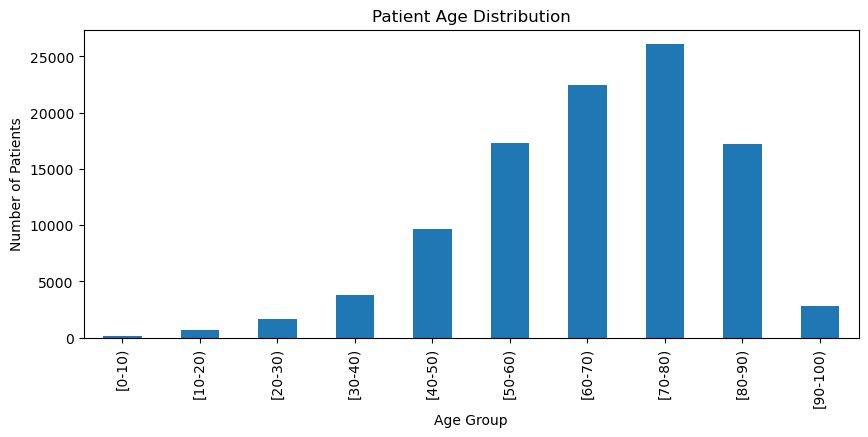

In [17]:
# ============================================================
# 7. Patient Age Distribution
# ============================================================
# Philosophy:
#
# Age is one of the most important demographic
# factors associated with diabetes outcomes and
# hospital readmissions.
#
# Exploring the age distribution helps us:
#
# - Understand the patient population
# - Identify the most represented age groups
# - Detect potential demographic biases
# - Gain domain knowledge before training
#   the machine learning model
#
# This visualization shows the number of patients
# in each age category within the dataset.
# ============================================================

df["age"].value_counts().sort_index().plot(
    kind="bar",
    figsize=(10,4)
)

plt.title("Patient Age Distribution")
plt.xlabel("Age Group")
plt.ylabel("Number of Patients")
plt.show()

In [18]:
# ============================================================
# 8. Basic Dataset Information
# ============================================================
# Philosophy:
#
# Before feature engineering and model training,
# it is important to understand the overall
# structure and quality of the dataset.
#
# This summary helps us:
#
# - Identify the types of features available
#   (categorical, numeric, etc.)
# - Understand the overall dataset composition
# - Quantify missing values across all columns
# - Detect potential data quality issues that
#   may require preprocessing
#
# These checks provide a high-level overview of
# the dataset and support informed modeling
# decisions later in the machine learning pipeline.
# ============================================================

print("\nColumn Types:")
print(df.dtypes.value_counts())

print("\nTotal Missing Values:")
print(df.isnull().sum().sum())


Column Types:
object    37
int64     13
Name: count, dtype: int64

Total Missing Values:
181168


In [19]:
# ============================================================
# 9. Convert Target into Binary Classification
# ============================================================
# Philosophy:
#
# The original dataset contains three possible
# readmission outcomes:
#
# - "<30" : Patient was readmitted within 30 days
# - ">30" : Patient was readmitted after 30 days
# - "NO"  : Patient was not readmitted
#
# For this project, the business objective is to
# identify patients at risk of early readmission.
#
# Therefore, we transform the problem into a
# binary classification task:
#
# - 1 = Readmitted within 30 days (high-risk)
# - 0 = Not readmitted within 30 days
#
# This code is written safely so the cell can be
# re-run without breaking if the target was already
# converted to 0 and 1.
# ============================================================

print("Target values before conversion:")
print(df[TARGET].value_counts(dropna=False))

df[TARGET] = df[TARGET].replace({
    "<30": 1,
    ">30": 0,
    "NO": 0
}).astype(int)

print("\nBinary Target Distribution:")
print(df[TARGET].value_counts())

Target values before conversion:
readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64

Binary Target Distribution:
readmitted
0    90409
1    11357
Name: count, dtype: int64


/tmp/ipykernel_9242/2189996636.py:30: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[TARGET] = df[TARGET].replace({


In [20]:
df['readmitted'].unique()

array([0, 1])

In [21]:
# ============================================================
# 10. Cost-safe stratified sample + realistic production reserve
# ============================================================
# Philosophy:
#
# The full diabetes dataset has more than 100,000 records.
# To control SageMaker training and batch transform cost,
# we train and validate on a stratified 15,000-row sample.
#
# IMPORTANT:
# We do NOT throw away the remaining rows.
# In a real ML system, future production data is different from
# the exact sample used for model development.
#
# Therefore:
# - df_sample is used for feature engineering, training, validation, and test
# - df_remaining is reserved as simulated production data
#
# This makes the production monitoring step more realistic.

df_sample, df_remaining = train_test_split(
    df,
    train_size=SAMPLE_SIZE,
    stratify=df[TARGET],
    random_state=RANDOM_STATE
)

df_sample = df_sample.reset_index(drop=True)
df_remaining = df_remaining.reset_index(drop=True)

print("Training/development sample shape:", df_sample.shape)
print("Remaining production candidate shape:", df_remaining.shape)

print("\nSample target distribution:")
print(df_sample[TARGET].value_counts(normalize=True))

print("\nRemaining production target distribution:")
print(df_remaining[TARGET].value_counts(normalize=True))

Training/development sample shape: (15000, 50)
Remaining production candidate shape: (86766, 50)

Sample target distribution:
readmitted
0    0.8884
1    0.1116
Name: proportion, dtype: float64

Remaining production target distribution:
readmitted
0    0.888401
1    0.111599
Name: proportion, dtype: float64


In [22]:
# ============================================================
# 11. Upload raw dataset to S3 Datalake
# ============================================================
# Philosophy:
#
# The project requires raw data to be stored in S3.
# This creates a simple datalake layer:
#
# raw/
#   diabetes/
#      diabetic_data.csv
#
# Athena can query this raw file using SQL before we train the model.

raw_s3_key = "raw/diabetes/diabetic_data.csv"

s3.upload_file(
    RAW_FILE,
    BUCKET_NAME,
    raw_s3_key
)

raw_s3_uri = f"s3://{BUCKET_NAME}/{raw_s3_key}"

print("Raw dataset uploaded to S3:")
print(raw_s3_uri)

Raw dataset uploaded to S3:
s3://aai540-diabetes-readmission-ali-2026/raw/diabetes/diabetic_data.csv


In [23]:
# ============================================================
# 12. Create Athena database and external table
# ============================================================
# Philosophy:
#
# Athena allows us to query raw S3 data using SQL.
# This satisfies the project step:
# "Set up Athena tables to enable cataloging and querying of your data."
#
# We use Athena only for lightweight EDA here, not for heavy processing,
# because the notebook already handles model preprocessing in pandas.

import time

athena = boto3.client("athena", region_name=REGION)

ATHENA_DATABASE = "aai540_diabetes_db"
ATHENA_OUTPUT = f"s3://{BUCKET_NAME}/athena-query-results/"

def run_athena_query(query, database="default"):
    response = athena.start_query_execution(
        QueryString=query,
        QueryExecutionContext={
            "Catalog": "AwsDataCatalog",
            "Database": database
        },
        ResultConfiguration={
            "OutputLocation": ATHENA_OUTPUT
        }
    )

    query_execution_id = response["QueryExecutionId"]

    while True:
        result = athena.get_query_execution(
            QueryExecutionId=query_execution_id
        )

        status = result["QueryExecution"]["Status"]["State"]

        if status in ["SUCCEEDED", "FAILED", "CANCELLED"]:
            break

        time.sleep(2)

    if status != "SUCCEEDED":
        raise RuntimeError(result["QueryExecution"]["Status"])

    return query_execution_id


create_db_query = f"""
CREATE DATABASE IF NOT EXISTS {ATHENA_DATABASE}
"""

run_athena_query(create_db_query, database="default")

print("Athena database ready:")
print(ATHENA_DATABASE)

Athena database ready:
aai540_diabetes_db


In [24]:
# ============================================================
# 13. Create Athena Raw Diabetes Table
# ============================================================
# Philosophy:
#
# - Defines the schema of the diabetes dataset
# - Maps CSV columns to Athena data types
# - Creates an external table that references
#   data stored in Amazon S3
# - Enables SQL-based exploration and analysis
#   of the dataset
#
# For simplicity, this first project version
# includes the primary columns required for
# exploratory data analysis and model training.
#
# Athena table location:
# s3://BUCKET/raw/diabetes/
# ============================================================

create_table_query = f"""
CREATE EXTERNAL TABLE IF NOT EXISTS {ATHENA_DATABASE}.diabetes_raw (
    encounter_id BIGINT,
    patient_nbr BIGINT,
    race STRING,
    gender STRING,
    age STRING,
    weight STRING,
    admission_type_id INT,
    discharge_disposition_id INT,
    admission_source_id INT,
    time_in_hospital INT,
    payer_code STRING,
    medical_specialty STRING,
    num_lab_procedures INT,
    num_procedures INT,
    num_medications INT,
    number_outpatient INT,
    number_emergency INT,
    number_inpatient INT,
    diag_1 STRING,
    diag_2 STRING,
    diag_3 STRING,
    number_diagnoses INT,
    max_glu_serum STRING,
    A1Cresult STRING,
    metformin STRING,
    repaglinide STRING,
    nateglinide STRING,
    chlorpropamide STRING,
    glimepiride STRING,
    acetohexamide STRING,
    glipizide STRING,
    glyburide STRING,
    tolbutamide STRING,
    pioglitazone STRING,
    rosiglitazone STRING,
    acarbose STRING,
    miglitol STRING,
    troglitazone STRING,
    tolazamide STRING,
    examide STRING,
    citoglipton STRING,
    insulin STRING,
    glyburide_metformin STRING,
    glipizide_metformin STRING,
    glimepiride_pioglitazone STRING,
    metformin_rosiglitazone STRING,
    metformin_pioglitazone STRING,
    change STRING,
    diabetesMed STRING,
    readmitted STRING
)
ROW FORMAT SERDE 'org.apache.hadoop.hive.serde2.OpenCSVSerde'
WITH SERDEPROPERTIES (
    "separatorChar" = ",",
    "quoteChar" = "\\""
)
LOCATION 's3://{BUCKET_NAME}/raw/diabetes/'
TBLPROPERTIES (
    "skip.header.line.count" = "1"
)
"""

run_athena_query(create_table_query, database=ATHENA_DATABASE)

print("Athena table ready:")
print(f"{ATHENA_DATABASE}.diabetes_raw")

Athena table ready:
aai540_diabetes_db.diabetes_raw


In [25]:
# ============================================================
# 14. Athena SQL EDA
# ============================================================
# Philosophy:
#
# This demonstrates that our raw S3 datalake is queryable.
# We use SQL to check:
# - total records
# - readmission class distribution
# - average hospital stay by readmission class
# ============================================================

eda_query = f"""
SELECT
    readmitted,
    COUNT(*) AS record_count,
    ROUND(AVG(time_in_hospital), 2) AS avg_time_in_hospital,
    ROUND(AVG(num_medications), 2) AS avg_num_medications,
    ROUND(AVG(number_inpatient), 2) AS avg_number_inpatient
FROM {ATHENA_DATABASE}.diabetes_raw
GROUP BY readmitted
ORDER BY record_count DESC
"""

eda_query_id = run_athena_query(eda_query, database=ATHENA_DATABASE)

eda_results_s3 = f"{ATHENA_OUTPUT}{eda_query_id}.csv"

print("Athena EDA query complete.")
print("Query result stored at:")
print(eda_results_s3)

athena_eda_df = pd.read_csv(eda_results_s3)

athena_eda_df

Athena EDA query complete.
Query result stored at:
s3://aai540-diabetes-readmission-ali-2026/athena-query-results/2dc0dde8-0a17-46cf-ada4-07da1c0bb0d3.csv


,readmitted,record_count,avg_time_in_hospital,avg_num_medications,avg_number_inpatient
0,NO,54864,4.25,15.67,0.38
1,>30,35545,4.50,16.28,0.84
2,<30,11357,4.77,16.90,1.22


In [26]:
# ============================================================
# 15. Check for Missing Value Placeholders
# ============================================================
# Philosophy:
#
# In the original diabetes dataset, some missing
# values are represented by the character "?"
# instead of a true null value.
#
# Before converting these placeholders to NaN,
# it is useful to understand:
#
# - How many placeholder values exist
# - Which features contain missing data
# - The overall quality of the dataset
# - Potential preprocessing requirements
#
# This inspection supports exploratory data
# analysis (EDA) and helps identify columns that
# may require cleaning before model training.
# ============================================================

question_counts = (df_sample == "?").sum()

print(
    question_counts[question_counts > 0]
    .sort_values(ascending=False)
)

weight               14552
medical_specialty     7343
payer_code            5954
race                   323
diag_3                 198
diag_2                  46
diag_1                   4
dtype: int64


In [27]:
# ============================================================
# 16. Select Features for Initial Model Version
# ============================================================
# Philosophy:
#
# Feature selection is an important step in the
# machine learning pipeline because it determines
# which patient characteristics will be used to
# train the model.
#
# For the first project version, we focus on a
# subset of clinically relevant features that are
# likely to influence hospital readmission risk.
#
# We intentionally exclude:
#
# - encounter_id
# - patient_nbr
#
# because they are unique identifiers and do not
# provide meaningful clinical information for
# prediction.
#
# We also limit the number of medication-related
# features in the initial model to:
#
# - Reduce model complexity
# - Improve interpretability
# - Simplify feature engineering
# - Establish a baseline model before exploring
#   additional predictors
#
# The selected features include demographic,
# admission, utilization, laboratory, and diabetes
# management information.
# ============================================================

features = [
    "race",
    "gender",
    "age",
    "admission_type_id",
    "discharge_disposition_id",
    "admission_source_id",
    "time_in_hospital",
    "num_lab_procedures",
    "num_procedures",
    "num_medications",
    "number_outpatient",
    "number_emergency",
    "number_inpatient",
    "number_diagnoses",
    "max_glu_serum",
    "A1Cresult",
    "change",
    "diabetesMed",
    "insulin"
]

# Create a modeling dataset containing only the
# selected features and target variable

df_model_raw = df_sample[features + [TARGET]].copy()

In [28]:
# ============================================================
# 17. Standardize Feature Names
# ============================================================
# Philosophy:
#
# Machine learning platforms and downstream AWS
# services often impose restrictions on feature
# names.
#
# To improve compatibility and consistency, we
# standardize column names by:
#
# - Replacing special characters with underscores
# - Removing repeated underscores
# - Ensuring names begin with a valid character
# - Limiting name length
#
# This preprocessing step helps avoid issues when
# storing features, training models, generating
# monitoring reports, and integrating with
# SageMaker services.
# ============================================================

import re

def clean_feature_name(col):
    """
    Convert column names into a standardized
    machine-learning-friendly format.
    """

    col = str(col)

    # Replace non-alphanumeric characters
    # with underscores
    col = re.sub(r"[^a-zA-Z0-9]", "_", col)

    # Collapse multiple consecutive
    # underscores into a single underscore
    col = re.sub(r"_+", "_", col)

    # Remove leading and trailing underscores
    col = col.strip("_")

    # Ensure the feature name starts with
    # an alphanumeric character
    if not re.match(r"^[a-zA-Z0-9]", col):
        col = "f_" + col

    # Limit feature name length to avoid
    # service-specific naming constraints
    col = col[:64]

    return col

In [29]:
# ============================================================
# 18. One-Hot Encode Categorical Features
# ============================================================
# Philosophy:
#
# Most machine learning algorithms require numeric
# inputs and cannot directly process categorical
# text values such as gender, race, or age groups.
#
# One-hot encoding transforms categorical features
# into binary indicator columns that can be used
# during model training.
#
# This step:
#
# - Converts categorical values into numeric form
# - Preserves category information
# - Enables compatibility with ML algorithms
# - Prepares features for SageMaker training
#
# After encoding, we also standardize feature
# names to satisfy SageMaker naming requirements
# and ensure compatibility with downstream AWS
# services.
# ============================================================

X = df_model_raw.drop(columns=[TARGET])
y = df_model_raw[TARGET]

# Convert categorical variables into binary
# indicator columns

X_encoded = pd.get_dummies(
    X,
    drop_first=True
)

# ============================================================
# 18A. Standardize Encoded Feature Names
# ============================================================
# Philosophy:
#
# One-hot encoding often generates feature names
# containing special characters inherited from
# the original category values.
#
# Examples:
#
# gender_Unknown/Invalid
# becomes
# gender_Unknown_Invalid
#
# age_[10-20)
# becomes
# age_10_20
#
# SageMaker Feature Store and other AWS services
# may reject feature names containing characters
# such as:
#
# / ( ) [ ] < >
#
# Therefore, we clean all feature names to ensure
# compatibility across the MLOps pipeline.
# ============================================================

X_encoded.columns = [
    clean_feature_name(col)
    for col in X_encoded.columns
]

# ============================================================
# 18B. Build Final Modeling Dataset
# ============================================================
# Philosophy:
#
# After feature engineering is complete, we
# combine the encoded features with the target
# variable to create the final dataset used for
# model training and evaluation.
#
# This dataset contains only machine-learning
# ready numeric features.
# ============================================================

# Create final feature matrix
df_model = X_encoded.copy()

# Add target variable back
df_model[TARGET] = y.values

print("\nFinal Model Dataset Shape:")
print(df_model.shape)

print("\nExample Feature Columns:")
print(df_model.columns[:20].tolist())


Final Model Dataset Shape:
(15000, 37)

Example Feature Columns:
['admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses', 'race_AfricanAmerican', 'race_Asian', 'race_Caucasian', 'race_Hispanic', 'race_Other', 'gender_Male', 'gender_Unknown_Invalid', 'age_10_20', 'age_20_30']


In [30]:
# ============================================================
# 19. Feature Store: Create or Reuse Feature Group Safely
# ============================================================
# Philosophy:
#
# SageMaker Feature Store provides a centralized
# repository for storing, managing, and reusing
# machine learning features.
#
# In an MLOps pipeline, the Feature Store helps:
#
# - Preserve engineered features for future use
# - Improve consistency between training and inference
# - Support feature governance and traceability
# - Store feature data in an offline store for
#   model training and analysis
#
# This step creates a SageMaker Feature Group
# using the engineered dataset prepared earlier.
#
# We use Boto3 instead of the older SageMaker
# FeatureGroup import because the older import may
# not work in the current SageMaker environment.
#
# The code is written safely so it can reuse an
# existing Feature Group instead of failing when
# the group already exists.
# ============================================================

import time

sm_client = boto3.client("sagemaker", region_name=REGION)
featurestore_runtime = boto3.client(
    "sagemaker-featurestore-runtime",
    region_name=REGION
)

sts = boto3.client("sts", region_name=REGION)
account_id = sts.get_caller_identity()["Account"]
role = f"arn:aws:iam::{account_id}:role/LabRole"

print("Using role:", role)

df_model = df_model.copy()
df_model["record_id"] = df_model.index.astype(str)
df_model["event_time"] = pd.Timestamp.utcnow().strftime("%Y-%m-%dT%H:%M:%SZ")

for col in df_model.columns:
    if df_model[col].dtype == "bool":
        df_model[col] = df_model[col].astype(int)

feature_definitions = []

for col in df_model.columns:
    if col == "event_time":
        feature_type = "String"
    elif pd.api.types.is_integer_dtype(df_model[col]):
        feature_type = "Integral"
    elif pd.api.types.is_float_dtype(df_model[col]):
        feature_type = "Fractional"
    else:
        feature_type = "String"

    feature_definitions.append({
        "FeatureName": col,
        "FeatureType": feature_type
    })

feature_group_name = "diabetes-readmission-feature-group-v2"

# Set this to True only the first time or when you intentionally want to re-ingest
RUN_INGESTION = False

try:
    sm_client.describe_feature_group(
        FeatureGroupName=feature_group_name
    )
    print("Feature Group already exists:", feature_group_name)

except sm_client.exceptions.ResourceNotFound:
    sm_client.create_feature_group(
        FeatureGroupName=feature_group_name,
        RecordIdentifierFeatureName="record_id",
        EventTimeFeatureName="event_time",
        FeatureDefinitions=feature_definitions,
        OfflineStoreConfig={
            "S3StorageConfig": {
                "S3Uri": f"s3://{BUCKET_NAME}/feature-store/"
            },
            "DisableGlueTableCreation": False
        },
        RoleArn=role
    )

    print("Creating Feature Group:", feature_group_name)

while True:
    response = sm_client.describe_feature_group(
        FeatureGroupName=feature_group_name
    )

    status = response["FeatureGroupStatus"]
    print("Feature Group status:", status)

    if status == "Created":
        break

    if status in ["CreateFailed", "DeleteFailed"]:
        raise Exception(f"Feature Group failed with status: {status}")

    time.sleep(30)

if RUN_INGESTION:
    for i, row in df_model.iterrows():
        record = []

        for col, value in row.items():
            if pd.isna(value):
                value = ""

            record.append({
                "FeatureName": col,
                "ValueAsString": str(value)
            })

        featurestore_runtime.put_record(
            FeatureGroupName=feature_group_name,
            Record=record
        )

        if i % 1000 == 0:
            print(f"Ingested {i} records...")

    print("Feature data ingested into SageMaker Feature Store.")
else:
    print("Skipping ingestion because RUN_INGESTION = False.")

print("Feature Group Name:", feature_group_name)
print("Offline Store Path:", f"s3://{BUCKET_NAME}/feature-store/")

Using role: arn:aws:iam::646180330281:role/LabRole
Feature Group already exists: diabetes-readmission-feature-group-v2


Feature Group status: Created
Skipping ingestion because RUN_INGESTION = False.
Feature Group Name: diabetes-readmission-feature-group-v2
Offline Store Path: s3://aai540-diabetes-readmission-ali-2026/feature-store/


In [31]:
# ============================================================
# 20. Split development sample into train / validation / test
# ============================================================
# Philosophy:
#
# The 15,000-row stratified sample is used only for development.
#
# From this sample:
# - 80% goes to training
# - 10% goes to validation
# - 10% goes to test
#
# Stratified sampling is used to preserve the
# original distribution of the target variable
# across all datasets.
#
# Note:
# The 15,000-row sample is used only for model
# development. The remaining records were not
# used during training and can represent future
# production data for monitoring and inference
# workflows.
# ============================================================

metadata_cols = ["record_id", "event_time"]

train_df, temp_df = train_test_split(
    df_model,
    test_size=0.20,
    stratify=df_model[TARGET],
    random_state=RANDOM_STATE
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df[TARGET],
    random_state=RANDOM_STATE
)

print("Train shape:", train_df.shape)
print("Validation shape:", val_df.shape)
print("Test shape:", test_df.shape)

Train shape: (12000, 39)
Validation shape: (1500, 39)
Test shape: (1500, 39)


In [32]:
# ============================================================
# 21. Build Production Dataset from Remaining Raw Records
# ============================================================
# Philosophy:
#
# In a real ML system, production data should be
# separate from the data used for model development.
#
# For this project, we simulate future production
# data by using records that were excluded from the
# 15,000-row training/development sample.
#
# This supports the MLOps monitoring workflow because
# the production batch represents unseen data that can
# be used for:
#
# - Batch inference
# - Model monitoring
# - Data quality checks
# - Drift analysis
#
# To control AWS cost and runtime, we sample a smaller
# production batch from the remaining records.
#
# The same preprocessing logic used for training is
# applied to the production data to keep feature formats
# consistent between development and inference.
# ============================================================

PRODUCTION_SIZE = 6000

df_production_raw, _ = train_test_split(
    df_remaining,
    train_size=PRODUCTION_SIZE,
    stratify=df_remaining[TARGET],
    random_state=RANDOM_STATE
)

df_production_raw = df_production_raw.reset_index(drop=True)
df_production_raw = df_production_raw.replace("?", np.nan)

# Use the same feature list as training
production_model_raw = df_production_raw[features + [TARGET]].copy()

X_production_raw = production_model_raw.drop(columns=[TARGET])
y_production = production_model_raw[TARGET]

# Apply the same one-hot encoding logic
X_production_encoded = pd.get_dummies(
    X_production_raw,
    drop_first=True
)

X_production_encoded.columns = [
    clean_feature_name(col)
    for col in X_production_encoded.columns
]

# Critical:
# Align production columns to training columns.
# Any missing dummy column becomes 0.
# Any unexpected production-only dummy column is removed.
X_production_encoded = X_production_encoded.reindex(
    columns=X_encoded.columns,
    fill_value=0
)

production_df = X_production_encoded.copy()
production_df[TARGET] = y_production.values

production_df["record_id"] = [
    f"prod_{i}" for i in range(len(production_df))
]

production_df["event_time"] = pd.Timestamp.utcnow().strftime(
    "%Y-%m-%dT%H:%M:%SZ"
)

print("Production dataset built from remaining raw data:")
print(production_df.shape)

print("\nProduction target distribution:")
print(production_df[TARGET].value_counts(normalize=True))

Production dataset built from remaining raw data:
(6000, 39)

Production target distribution:
readmitted
0    0.888333
1    0.111667
Name: proportion, dtype: float64


In [33]:
# ============================================================
# 22. Save Processed Datasets Locally
# ============================================================
# Philosophy:
#
# After preprocessing and dataset preparation,
# we save the resulting datasets locally so they
# can be uploaded to Amazon S3 for training,
# validation, testing, and production workflows.
#
# This step:
#
# - Preserves the processed datasets
# - Creates a reproducible training pipeline
# - Separates development and production data
# - Prepares files for SageMaker consumption
#
# The datasets include:
#
# - Training dataset
# - Validation dataset
# - Test dataset
# - Simulated production dataset
#
# These files will be uploaded to the project
# data lake and used in subsequent MLOps stages.
# ============================================================

os.makedirs("/tmp/aai540_diabetes", exist_ok=True)

train_path = "/tmp/aai540_diabetes/train.csv"
val_path = "/tmp/aai540_diabetes/validation.csv"
test_path = "/tmp/aai540_diabetes/test.csv"
production_path = "/tmp/aai540_diabetes/production.csv"

train_df.to_csv(train_path, index=False)
val_df.to_csv(val_path, index=False)
test_df.to_csv(test_path, index=False)
production_df.to_csv(production_path, index=False)

print("Files saved locally.")

Files saved locally.


In [34]:
# ============================================================
# 23. Upload Processed Datasets to Amazon S3
# ============================================================
# Philosophy:
#
# Amazon S3 serves as the central storage layer
# of the project data lake architecture.
#
# After preprocessing, the datasets are uploaded
# to S3 so they can be accessed by SageMaker and
# other AWS services throughout the MLOps pipeline.
#
# This step:
#
# - Stores training data for model development
# - Stores validation and test datasets for
#   evaluation workflows
# - Stores simulated production data for
#   monitoring and inference workflows
# - Creates a reproducible and centralized
#   dataset repository
#
# The uploaded datasets will be used in later
# stages including model training, batch
# prediction, monitoring, and observability.
# ============================================================

s3.upload_file(train_path, BUCKET_NAME, "processed/sample/train.csv")
s3.upload_file(val_path, BUCKET_NAME, "processed/sample/validation.csv")
s3.upload_file(test_path, BUCKET_NAME, "processed/sample/test.csv")

s3.upload_file(
    production_path,
    BUCKET_NAME,
    "processed/production/production_from_remaining_raw.csv"
)

print("Processed datasets uploaded to S3.")

print("\nTraining Data:")
print(f"s3://{BUCKET_NAME}/processed/sample/train.csv")

print("\nValidation Data:")
print(f"s3://{BUCKET_NAME}/processed/sample/validation.csv")

print("\nTest Data:")
print(f"s3://{BUCKET_NAME}/processed/sample/test.csv")

print("\nProduction Data:")
print(f"s3://{BUCKET_NAME}/processed/production/production_from_remaining_raw.csv")

Processed datasets uploaded to S3.

Training Data:
s3://aai540-diabetes-readmission-ali-2026/processed/sample/train.csv

Validation Data:
s3://aai540-diabetes-readmission-ali-2026/processed/sample/validation.csv

Test Data:
s3://aai540-diabetes-readmission-ali-2026/processed/sample/test.csv

Production Data:
s3://aai540-diabetes-readmission-ali-2026/processed/production/production_from_remaining_raw.csv


In [35]:
# ============================================================
# 24. Prepare Training, Validation, and Test Features
# ============================================================
# Philosophy:
#
# Machine learning models learn from input features
# and attempt to predict a target variable.
#
# Before training, we separate each dataset into:
#
# - Features (X)
#     Input variables used by the model
#
# - Target (y)
#     Outcome variable the model will predict
#
# We remove:
#
# - readmitted
#     Because it is the prediction target and
#     must not be used as an input feature.
#
# - record_id
# - event_time
#
#     Because these columns were created for
#     Feature Store management and tracking.
#     They are metadata fields, not clinical
#     predictors, and should not influence
#     model training.
#
# The resulting datasets contain only
# machine-learning-ready feature columns.
# ============================================================

X_train = train_df.drop(columns=[TARGET] + metadata_cols)
y_train = train_df[TARGET]

X_val = val_df.drop(columns=[TARGET] + metadata_cols)
y_val = val_df[TARGET]

X_test = test_df.drop(columns=[TARGET] + metadata_cols)
y_test = test_df[TARGET]

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)

X_train: (12000, 36)
X_val: (1500, 36)
X_test: (1500, 36)


In [36]:
# ============================================================
# 25. Train Baseline Logistic Regression Model
# ============================================================
# Philosophy:
#
# Before evaluating more advanced machine learning
# models, it is important to establish a baseline
# benchmark.
#
# Logistic Regression is commonly used as a
# baseline because it is:
#
# - Simple and interpretable
# - Fast to train
# - Widely used in healthcare analytics
# - Easy to explain to stakeholders
#
# The performance of more complex models such as
# XGBoost should be compared against this baseline
# to determine whether additional complexity
# provides meaningful improvement.
#
# Because hospital readmission datasets are often
# imbalanced, class_weight="balanced" is used to
# reduce bias toward the majority class.
# ============================================================

log_model = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    random_state=RANDOM_STATE
)

# Train the baseline model using the
# training dataset

log_model.fit(X_train, y_train)

# Generate predictions for the
# validation dataset

log_pred = log_model.predict(X_val)

# Generate prediction probabilities
# for ROC-AUC evaluation

log_prob = log_model.predict_proba(X_val)[:, 1]

# Calculate evaluation metrics

log_metrics = {
    "model": "Logistic Regression Benchmark",
    "accuracy": accuracy_score(y_val, log_pred),
    "precision": precision_score(y_val, log_pred),
    "recall": recall_score(y_val, log_pred),
    "f1": f1_score(y_val, log_pred),
    "roc_auc": roc_auc_score(y_val, log_prob)
}

print("Logistic Regression Metrics:")
print(json.dumps(log_metrics, indent=2))

print("\nClassification Report:")
print(classification_report(y_val, log_pred))

Logistic Regression Metrics:
{
  "model": "Logistic Regression Benchmark",
  "accuracy": 0.682,
  "precision": 0.17745302713987474,
  "recall": 0.5059523809523809,
  "f1": 0.26275115919629055,
  "roc_auc": 0.644546332046332
}

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.70      0.80      1332
           1       0.18      0.51      0.26       168

    accuracy                           0.68      1500
   macro avg       0.55      0.61      0.53      1500
weighted avg       0.84      0.68      0.74      1500



In [37]:
# ============================================================
# 26. Train Improved XGBoost Model
# ============================================================
# Philosophy:
#
# After establishing a Logistic Regression baseline,
# we train a stronger model for tabular healthcare
# data.
#
# XGBoost is often effective for structured/tabular
# datasets because it can capture nonlinear patterns
# and feature interactions better than a simple
# linear model.
#
# In this project, the positive class represents
# patients readmitted within 30 days. Since this
# class is less common, the dataset is imbalanced.
#
# scale_pos_weight is calculated to give more
# importance to the minority class during training.
#
# The XGBoost model will be compared against the
# Logistic Regression benchmark to determine whether
# the more complex model provides better predictive
# performance.
# ============================================================

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

print("scale_pos_weight:", scale_pos_weight)

xgb_model = XGBClassifier(
    n_estimators=150,
    max_depth=4,
    learning_rate=0.08,
    subsample=0.9,
    colsample_bytree=0.9,
    scale_pos_weight=scale_pos_weight,
    random_state=RANDOM_STATE,
    eval_metric="logloss"
)

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_val)
xgb_prob = xgb_model.predict_proba(X_val)[:, 1]

xgb_metrics = {
    "model": "XGBoost",
    "accuracy": accuracy_score(y_val, xgb_pred),
    "precision": precision_score(y_val, xgb_pred),
    "recall": recall_score(y_val, xgb_pred),
    "f1": f1_score(y_val, xgb_pred),
    "roc_auc": roc_auc_score(y_val, xgb_prob)
}

print("XGBoost Validation Metrics:")
print(json.dumps(xgb_metrics, indent=2))

print("\nClassification Report:")
print(classification_report(y_val, xgb_pred))

scale_pos_weight: 7.961911874533234


XGBoost Validation Metrics:
{
  "model": "XGBoost",
  "accuracy": 0.684,
  "precision": 0.16883116883116883,
  "recall": 0.4642857142857143,
  "f1": 0.24761904761904763,
  "roc_auc": 0.621067496067496
}

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.71      0.80      1332
           1       0.17      0.46      0.25       168

    accuracy                           0.68      1500
   macro avg       0.54      0.59      0.52      1500
weighted avg       0.83      0.68      0.74      1500



In [38]:
# ============================================================
# 27. Final Model Evaluation on Test Dataset
# ============================================================
# Philosophy:
#
# The validation dataset was used during model
# development to compare candidate models and
# guide model selection.
#
# After selecting XGBoost as the preferred model,
# we evaluate it on the test dataset.
#
# The test dataset was not used during training
# or model selection, making it the most reliable
# estimate of how the model may perform on unseen
# future data.
#
# This final evaluation helps assess:
#
# - Overall predictive performance
# - Classification quality
# - Generalization to unseen records
# - Readiness for deployment and monitoring
#
# In addition to standard classification metrics,
# a confusion matrix is generated to examine the
# distribution of correct and incorrect predictions.
# ============================================================

test_pred = xgb_model.predict(X_test)
test_prob = xgb_model.predict_proba(X_test)[:, 1]

test_metrics = {
    "model": "XGBoost Final Test",
    "accuracy": accuracy_score(y_test, test_pred),
    "precision": precision_score(y_test, test_pred),
    "recall": recall_score(y_test, test_pred),
    "f1": f1_score(y_test, test_pred),
    "roc_auc": roc_auc_score(y_test, test_prob),
    "confusion_matrix": confusion_matrix(y_test, test_pred).tolist()
}

print("XGBoost Final Test Metrics:")
print(json.dumps(test_metrics, indent=2))

XGBoost Final Test Metrics:
{
  "model": "XGBoost Final Test",
  "accuracy": 0.6826666666666666,
  "precision": 0.16630669546436286,
  "recall": 0.46107784431137727,
  "f1": 0.24444444444444444,
  "roc_auc": 0.6573394845717417,
  "confusion_matrix": [
    [
      947,
      386
    ],
    [
      90,
      77
    ]
  ]
}


In [39]:
# ============================================================
# 28. Save Model and Evaluation Artifacts
# ============================================================
# Philosophy:
#
# After training and evaluating the selected model,
# we preserve both the model and its evaluation
# results for future use.
#
# This step supports MLOps best practices by:
#
# - Saving the trained model artifact
# - Preserving model performance metrics
# - Recording project configuration details
# - Enabling reproducibility and traceability
# - Supporting future deployment workflows
#
# The model artifact contains the trained XGBoost
# model, while the metrics file documents model
# performance and key project metadata.
#
# Both artifacts are uploaded to Amazon S3 to
# provide centralized storage and versionable
# access across the machine learning lifecycle.
# ============================================================

model_path = "/tmp/aai540_diabetes/xgboost_model.pkl"
metrics_path = "/tmp/aai540_diabetes/model_metrics.json"

joblib.dump(xgb_model, model_path)

with open(metrics_path, "w") as f:
    json.dump(
        {
            "logistic_regression_validation": log_metrics,
            "xgboost_validation": xgb_metrics,
            "xgboost_test": test_metrics,
            "sample_size": SAMPLE_SIZE,
            "feature_group_name": feature_group_name,
            "feature_store_path": f"s3://{BUCKET_NAME}/feature-store/",
            "processed_data_path": f"s3://{BUCKET_NAME}/processed/sample/"
        },
        f,
        indent=2
    )

s3.upload_file(
    model_path,
    BUCKET_NAME,
    "models/sample/xgboost_model.pkl"
)

s3.upload_file(
    metrics_path,
    BUCKET_NAME,
    "models/sample/model_metrics.json"
)

print("Model and metrics uploaded to S3.")

print("\nModel Artifact:")
print(f"s3://{BUCKET_NAME}/models/sample/xgboost_model.pkl")

print("\nMetrics Artifact:")
print(f"s3://{BUCKET_NAME}/models/sample/model_metrics.json")

Model and metrics uploaded to S3.

Model Artifact:
s3://aai540-diabetes-readmission-ali-2026/models/sample/xgboost_model.pkl

Metrics Artifact:
s3://aai540-diabetes-readmission-ali-2026/models/sample/model_metrics.json


In [40]:
# ============================================================
# 29. Generate Production-Style Batch Predictions
# ============================================================
# Philosophy:
#
# After training and evaluating the model, we
# simulate a real-world inference workflow using
# previously unseen production data.
#
# In production environments, models typically
# receive new records and generate predictions
# without access to the true outcome.
#
# This step demonstrates batch inference by:
#
# - Loading production-style feature data
# - Generating prediction probabilities
# - Producing binary readmission predictions
# - Saving prediction results for downstream use
#
# The output dataset contains both:
#
# - Predicted class labels
# - Prediction probabilities
#
# These results can later be analyzed for:
#
# - Business decision support
# - Model monitoring
# - Performance tracking
# - Data drift detection
#
# Note:
# This implementation performs local batch scoring.
# In a production AWS environment, the same process
# can be executed using SageMaker Batch Transform.
# ============================================================

X_prod = production_df.drop(columns=[TARGET] + metadata_cols)

prod_prob = xgb_model.predict_proba(X_prod)[:, 1]
prod_pred = (prod_prob >= 0.5).astype(int)

production_output = production_df.copy()

production_output["predicted_readmitted_30_days"] = prod_pred
production_output["prediction_probability"] = prod_prob

production_output_path = "/tmp/aai540_diabetes/production_predictions.csv"

production_output.to_csv(
    production_output_path,
    index=False
)

s3.upload_file(
    production_output_path,
    BUCKET_NAME,
    "batch-output/sample/production_predictions.csv"
)

print("Production-style predictions uploaded.")

print("\nBatch Prediction Output:")
print(
    f"s3://{BUCKET_NAME}/batch-output/sample/production_predictions.csv"
)

production_output.head()

Production-style predictions uploaded.

Batch Prediction Output:
s3://aai540-diabetes-readmission-ali-2026/batch-output/sample/production_predictions.csv


,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,...,change_No,diabetesMed_Yes,insulin_No,insulin_Steady,insulin_Up,readmitted,record_id,event_time,predicted_readmitted_30_days,prediction_probability
0,1,1,7,12,61,6,32,0,0,0,...,True,True,False,True,False,0,prod_0,2026-06-08T06:00:48Z,0,0.456902
1,1,1,7,4,36,4,23,0,0,0,...,False,True,False,True,False,0,prod_1,2026-06-08T06:00:48Z,0,0.409410
2,6,1,7,7,64,0,16,0,0,0,...,True,False,True,False,False,0,prod_2,2026-06-08T06:00:48Z,0,0.356676
3,3,1,1,2,41,0,3,0,0,0,...,True,True,False,True,False,0,prod_3,2026-06-08T06:00:48Z,0,0.342964
4,1,1,7,6,41,0,21,0,0,0,...,True,True,True,False,False,0,prod_4,2026-06-08T06:00:48Z,0,0.356342


In [41]:
# ============================================================
# 30. Prepare Input Data for SageMaker Batch Transform
# ============================================================
# Philosophy:
#
# SageMaker Batch Transform performs large-scale
# offline inference using a trained model.
#
# Before submitting a Batch Transform job, the
# input dataset must contain only the feature
# columns used during training.
#
# Therefore, we remove:
#
# - readmitted
#     Because it is the true outcome label and
#     would not be available during inference.
#
# - record_id
# - event_time
#
#     Because these are Feature Store metadata
#     fields and not model input features.
#
# The resulting dataset simulates real production
# inference data and is formatted according to the
# requirements of the SageMaker built-in XGBoost
# container.
#
# SageMaker built-in XGBoost expects:
#
# - CSV format
# - No header row
# - No index column
#
# The prepared file is uploaded to Amazon S3 and
# will be used as input for the Batch Transform job.
# ============================================================

metadata_cols = ["record_id", "event_time"]

X_batch = production_df.drop(columns=[TARGET] + metadata_cols)

batch_input_path = "/tmp/aai540_diabetes/batch_input.csv"

# SageMaker built-in XGBoost expects CSV
# with no header and no index

X_batch.to_csv(
    batch_input_path,
    index=False,
    header=False
)

s3.upload_file(
    batch_input_path,
    BUCKET_NAME,
    "batch-input/sample/batch_input.csv"
)

batch_input_s3 = (
    f"s3://{BUCKET_NAME}/batch-input/sample/batch_input.csv"
)

print("Batch input uploaded:")
print(batch_input_s3)

print("Batch input shape:")
print(X_batch.shape)

Batch input uploaded:
s3://aai540-diabetes-readmission-ali-2026/batch-input/sample/batch_input.csv
Batch input shape:
(6000, 36)


In [42]:
# ============================================================
# 31. Create SageMaker-Compatible XGBoost Model Artifact
# ============================================================
# Philosophy:
#
# The XGBoost model trained inside the notebook
# exists only within the current Python session.
#
# To support deployment and Batch Transform,
# SageMaker requires the trained model to be
# packaged as a portable model artifact.
#
# For the SageMaker built-in XGBoost container:
#
# - The trained booster must be saved as
#   "xgboost-model"
#
# - The model file must be packaged inside a
#   model.tar.gz archive
#
# - The archive must be uploaded to Amazon S3
#
# This artifact becomes the deployable version
# of the model and can be used by:
#
# - SageMaker Batch Transform
# - SageMaker Endpoints
# - Future inference workflows
#
# In MLOps terminology, this is the model artifact
# that moves from development into deployment.
# ============================================================

import os
import tarfile

model_dir = "/tmp/aai540_diabetes/sagemaker_model"
os.makedirs(model_dir, exist_ok=True)

# Save only the XGBoost booster, not the sklearn wrapper
booster_path = os.path.join(model_dir, "xgboost-model")
xgb_model.get_booster().save_model(booster_path)

# Create model.tar.gz
model_tar_path = "/tmp/aai540_diabetes/model.tar.gz"

with tarfile.open(model_tar_path, "w:gz") as tar:
    tar.add(booster_path, arcname="xgboost-model")

# Upload model artifact to S3
s3.upload_file(
    model_tar_path,
    BUCKET_NAME,
    "models/sagemaker-xgboost/model.tar.gz"
)

model_artifact_s3 = f"s3://{BUCKET_NAME}/models/sagemaker-xgboost/model.tar.gz"

print("SageMaker model artifact uploaded:")
print(model_artifact_s3)

SageMaker model artifact uploaded:
s3://aai540-diabetes-readmission-ali-2026/models/sagemaker-xgboost/model.tar.gz


/opt/conda/lib/python3.12/site-packages/xgboost/core.py:158: UserWarning: [06:01:23] WARNING: /home/conda/feedstock_root/build_artifacts/xgboost-split_1744329020674/work/src/c_api/c_api.cc:1374: Saving model in the UBJSON format as default.  You can use file extension: `json`, `ubj` or `deprecated` to choose between formats.
  warnings.warn(smsg, UserWarning)


In [43]:
# ============================================================
# 32. Create SageMaker Model Object using Boto3
# ============================================================
# Philosophy:
#
# After creating a SageMaker-compatible model
# artifact, we register it as a SageMaker Model
# object.
#
# A SageMaker Model object connects three things:
#
# - The trained model artifact stored in S3
# - The AWS-managed XGBoost inference container
# - The IAM execution role used by SageMaker
#
# The XGBoost inference container is a pre-built
# Docker image provided and maintained by AWS.
# It contains the runtime environment, XGBoost
# libraries, and inference logic needed to load
# the trained model and generate predictions.
#
# This step does not retrain the model.
# Instead, it tells SageMaker:
#
# - Where the trained model artifact is stored
# - Which Docker container should execute it
# - Which IAM role should be used
#
# The created model object can then be used for:
#
# - Batch Transform jobs
# - Real-time inference endpoints
# - Future deployment workflows
#
# We use Boto3 directly because the current
# SageMaker environment does not expose the
# image_uris helper through the SDK.
#
# This step marks the transition from model
# development into deployment infrastructure.
# ============================================================
import time
import boto3

sm_client = boto3.client("sagemaker", region_name=REGION)

# AWS-managed SageMaker XGBoost image for us-east-1
xgboost_image_uri = (
    "683313688378.dkr.ecr.us-east-1.amazonaws.com/sagemaker-xgboost:1.7-1"
)

model_name = f"diabetes-xgboost-model-{int(time.time())}"

sm_client.create_model(
    ModelName=model_name,
    ExecutionRoleArn=role,
    PrimaryContainer={
        "Image": xgboost_image_uri,
        "ModelDataUrl": model_artifact_s3
    }
)

print("SageMaker model created:")
print(model_name)

print("Using image:")
print(xgboost_image_uri)

print("Using model artifact:")
print(model_artifact_s3)

SageMaker model created:
diabetes-xgboost-model-1780898508
Using image:
683313688378.dkr.ecr.us-east-1.amazonaws.com/sagemaker-xgboost:1.7-1
Using model artifact:
s3://aai540-diabetes-readmission-ali-2026/models/sagemaker-xgboost/model.tar.gz


In [44]:
# ============================================================
# 33. Prepare Production Data for Batch Transform
# ============================================================
# Philosophy:
#
# Before running a SageMaker Batch Transform job,
# the production dataset must match the feature
# structure used during model training.
#
# Machine learning models expect the same:
#
# - Feature columns
# - Feature order
# - Data types
#
# that were present during training.
#
# This step prepares the production dataset by:
#
# - Removing the target variable
# - Removing Feature Store metadata fields
# - Aligning columns to the training schema
# - Converting boolean values to numeric format
# - Converting all features to numeric values
# - Replacing missing values with defaults
#
# These checks help prevent inference failures
# caused by schema mismatches between training
# and production data.
#
# The final output is exported as a headerless
# CSV file because SageMaker built-in XGBoost
# expects:
#
# - Numeric features only
# - No header row
# - No target column
#
# The prepared file is uploaded to Amazon S3
# and will serve as input for the Batch
# Transform job.
# ============================================================

batch_features_df = production_df.drop(
    columns=[TARGET, "record_id", "event_time"],
    errors="ignore"
)

batch_features_df = batch_features_df.reindex(
    columns=X_encoded.columns,
    fill_value=0
)

# Convert boolean columns True/False to numeric 1/0
bool_cols = batch_features_df.select_dtypes(include=["bool"]).columns

batch_features_df[bool_cols] = batch_features_df[bool_cols].astype(int)

# Force every column to numeric
batch_features_df = batch_features_df.apply(
    pd.to_numeric,
    errors="coerce"
)

# Replace any remaining missing values with 0
batch_features_df = batch_features_df.fillna(0)

print("Batch feature shape:", batch_features_df.shape)
print("Training feature shape:", X_encoded.shape)
print("Columns match training:", list(batch_features_df.columns) == list(X_encoded.columns))
print("NaN count:", batch_features_df.isna().sum().sum())
print("Boolean columns remaining:", len(batch_features_df.select_dtypes(include=["bool"]).columns))

batch_file = "batch_input.csv"

batch_features_df.to_csv(
    batch_file,
    index=False,
    header=False
)

batch_s3_key = "batch-input/production/batch_input.csv"

s3.upload_file(
    batch_file,
    BUCKET_NAME,
    batch_s3_key
)

batch_input_s3_uri = f"s3://{BUCKET_NAME}/{batch_s3_key}"

print("Batch input uploaded to:")
print(batch_input_s3_uri)

Batch feature shape: (6000, 36)
Training feature shape: (15000, 36)
Columns match training: True
NaN count: 0
Boolean columns remaining: 0
Batch input uploaded to:
s3://aai540-diabetes-readmission-ali-2026/batch-input/production/batch_input.csv


In [45]:
# ============================================================
# 34. Create and Run SageMaker Batch Transform Job
# ============================================================
# Philosophy:
#
# SageMaker Batch Transform is used to generate
# offline predictions on a batch of production-style
# records.
#
# This step sends the prepared feature-only CSV
# file to the SageMaker Model object created in
# the previous step.
#
# The SageMaker Model object combines:
#
# - The trained XGBoost model artifact
# - The AWS-managed XGBoost Docker container
# - The IAM execution role
#
# Batch Transform then:
#
# - Loads the trained model from S3
# - Reads the batch input file from S3
# - Runs inference record by record
# - Writes prediction outputs back to S3
#
# This simulates a real production workflow where
# new patient records are scored in bulk without
# retraining the model.
#
# The input file contains features only because
# real production inference does not include the
# true readmission outcome at prediction time.
# ============================================================


sm_client = boto3.client("sagemaker", region_name=REGION)

transform_job_name = f"diabetes-batch-transform-{int(time.time())}"

batch_output_s3 = f"s3://{BUCKET_NAME}/batch-transform-output/production/"

sm_client.create_transform_job(
    TransformJobName=transform_job_name,
    ModelName=model_name,
    MaxConcurrentTransforms=1,
    MaxPayloadInMB=6,
    BatchStrategy="SingleRecord",
    TransformInput={
        "DataSource": {
            "S3DataSource": {
                "S3DataType": "S3Prefix",
                "S3Uri": batch_input_s3_uri
            }
        },
        "ContentType": "text/csv",
        "SplitType": "Line"
    },
    TransformOutput={
        "S3OutputPath": batch_output_s3,
        "Accept": "text/csv",
        "AssembleWith": "Line"
    },
    TransformResources={
        "InstanceType": "ml.m5.large",
        "InstanceCount": 1
    }
)

print("Batch Transform job started:")
print(transform_job_name)

print("Batch input path:")
print(batch_input_s3_uri)

print("Batch output path:")
print(batch_output_s3)

Batch Transform job started:
diabetes-batch-transform-1780898517
Batch input path:
s3://aai540-diabetes-readmission-ali-2026/batch-input/production/batch_input.csv
Batch output path:
s3://aai540-diabetes-readmission-ali-2026/batch-transform-output/production/


In [46]:
# ============================================================
# 35. Monitor Batch Transform Job
# ============================================================
# Philosophy:
#
# Batch Transform jobs execute asynchronously
# inside SageMaker.
#
# After submitting the job, SageMaker begins
# provisioning resources, loading the model,
# reading the input data, and generating
# predictions.
#
# This monitoring loop periodically checks the
# job status until processing completes or fails.
#
# Possible statuses include:
#
# - InProgress
#     SageMaker is currently processing records.
#
# - Completed
#     Predictions were successfully generated and
#     written to the specified S3 output location.
#
# - Failed
#     An error occurred during model loading,
#     input processing, or prediction generation.
#
# - Stopped
#     The job was manually terminated.
#
# Monitoring long-running jobs is a common MLOps
# practice because cloud-based training and
# inference workflows often execute asynchronously.
# ============================================================

import time

while True:

    response = sm_client.describe_transform_job(
        TransformJobName=transform_job_name
    )

    status = response["TransformJobStatus"]

    print("Current status:", status)

    if status == "Completed":
        print("\nBatch Transform completed successfully.")
        break

    if status in ["Failed", "Stopped"]:
        print("\nBatch Transform failed.")
        print(response)
        break

    time.sleep(30)

Current status: InProgress


Current status: InProgress


Current status: InProgress


Current status: InProgress


Current status: InProgress


...

Current status: InProgress


Current status: InProgress


Current status: InProgress


Current status: InProgress


Current status: Completed

Batch Transform completed successfully.


In [47]:
response = sm_client.describe_transform_job(
    TransformJobName=transform_job_name
)

print(response["TransformOutput"]["S3OutputPath"])

s3://aai540-diabetes-readmission-ali-2026/batch-transform-output/production/


In [51]:
# ============================================================
# 36. Retrieve and Verify Batch Transform Output
# ============================================================
# Philosophy:
#
# After the Batch Transform job completes,
# SageMaker stores prediction results in the
# specified Amazon S3 output location.
#
# This step retrieves the generated prediction
# file so we can inspect and validate the
# inference results.
#
# The workflow:
#
# - Locate the Batch Transform output file
# - Verify that prediction output was created
# - Download the file locally
# - Prepare for result inspection and analysis
#
# Successful completion of this step confirms
# that:
#
# - The model artifact loaded correctly
# - The inference container executed successfully
# - Production records were scored
# - Predictions were written to Amazon S3
#
# This is still part of the deployment and
# inference workflow rather than model quality
# monitoring.
# ============================================================

import boto3

s3 = boto3.client("s3")

batch_output_prefix = "batch-transform-output/"

response = s3.list_objects_v2(
    Bucket=BUCKET_NAME,
    Prefix=batch_output_prefix
)

output_files = [
    obj["Key"]
    for obj in response.get("Contents", [])
    if obj["Key"].endswith(".out")
]

if len(output_files) == 0:
    raise FileNotFoundError(
        f"No Batch Transform .out file found under s3://{BUCKET_NAME}/{batch_output_prefix}"
    )

output_key = output_files[0]

local_output_file = "/tmp/batch_predictions.out"

s3.download_file(
    BUCKET_NAME,
    output_key,
    local_output_file
)

print("Output file:", output_key)
print("Downloaded:", local_output_file)

Output file: batch-transform-output/production/batch_input.csv.out
Downloaded: /tmp/batch_predictions.out


In [52]:
# ============================================================
# 37. Inspect Batch Transform Predictions
# ============================================================
# Philosophy:
#
# After retrieving the Batch Transform output,
# we inspect the prediction results generated by
# the deployed XGBoost model.
# The Batch Transform job successfully generated readmission risk scores for the 6,000 production-style records.
# At this stage, we have predictions but have not yet compared them against actual outcomes.
#
# This step helps verify:
#
# - Predictions were successfully generated
# - The output file format is correct
# - The number of predictions matches the number
#   of production records submitted
# - The inference pipeline executed as expected
#
# For binary classification, each prediction
# typically represents the model's estimated
# probability of readmission within 30 days.
#
# This inspection validates the inference output
# before performing any further analysis,
# monitoring, or evaluation.
# ============================================================

import pandas as pd

predictions_df = pd.read_csv(
    local_output_file,
    header=None
)

print(predictions_df.head(10))

print("\nShape:", predictions_df.shape)

          0
0  0.456902
1  0.409410
2  0.356676
3  0.342964
4  0.356342
5  0.243997
6  0.337121
7  0.798042
8  0.635817
9  0.444732

Shape: (6000, 1)


In [53]:
# ============================================================
# 38. Prepare SageMaker Predictions for Monitoring
# ============================================================
# Philosophy:
#
# After Batch Transform generates prediction scores,
# we prepare those predictions for monitoring and
# evaluation.
#
# During real production inference, the true outcome
# is not available immediately because we do not yet
# know whether the patient will be readmitted within
# 30 days.
#
# However, in this project, our production dataset
# comes from historical records, so the true
# readmission outcome is available in production_df.
#
# This allows us to simulate a post-deployment
# monitoring workflow:
#
# - At inference time:
#     The model generates readmission risk scores.
#
# - After the outcome window:
#     The actual readmission outcome becomes known.
#
# - During monitoring:
#     Predictions are compared against actual
#     outcomes to evaluate model quality.
#
# This step cleans the SageMaker prediction output,
# converts probabilities into binary predictions,
# validates row alignment, and attaches predictions
# back to the production evaluation dataset.
# ============================================================

import pandas as pd

# ------------------------------------------------------------
# 1. Inspect and clean SageMaker Batch Transform output
# ------------------------------------------------------------
# Sometimes Batch Transform output contains more than one column.
# The prediction probability is the last column.

print("Predictions shape before cleanup:", predictions_df.shape)
display(predictions_df.head())

predictions_df = predictions_df.iloc[:, [-1]].copy()

predictions_df.columns = [
    "sagemaker_prediction_probability"
]

predictions_df["sagemaker_prediction_probability"] = pd.to_numeric(
    predictions_df["sagemaker_prediction_probability"],
    errors="coerce"
)

predictions_df = predictions_df.fillna(0)

print("Predictions shape after cleanup:", predictions_df.shape)
display(predictions_df.head())

# ------------------------------------------------------------
# 2. Convert probability into binary prediction
# ------------------------------------------------------------

predictions_df[
    "sagemaker_predicted_readmitted_30_days"
] = (
    predictions_df[
        "sagemaker_prediction_probability"
    ] >= 0.50
).astype(int)

# ------------------------------------------------------------
# 3. Align indexes
# ------------------------------------------------------------

production_eval_df = production_df.reset_index(
    drop=True
).copy()

predictions_df = predictions_df.reset_index(
    drop=True
)

# ------------------------------------------------------------
# 4. Validate row counts before joining
# ------------------------------------------------------------

print("Production rows:", len(production_eval_df))
print("Prediction rows:", len(predictions_df))

if len(production_eval_df) != len(predictions_df):
    raise ValueError(
        "Production rows and prediction rows do not match. "
        "Check Batch Transform input/output alignment."
    )

# ------------------------------------------------------------
# 5. Attach predictions to production dataset
# ------------------------------------------------------------

production_eval_df[
    "sagemaker_prediction_probability"
] = predictions_df[
    "sagemaker_prediction_probability"
]

production_eval_df[
    "sagemaker_predicted_readmitted_30_days"
] = predictions_df[
    "sagemaker_predicted_readmitted_30_days"
]

# ------------------------------------------------------------
# 6. Preview monitoring dataset
# ------------------------------------------------------------

print(
    "\nProduction evaluation dataset shape:",
    production_eval_df.shape
)

print("\nMonitoring dataset preview:")
print("\nThirty days later, the hospital learned who was actually readmitted and can now measure model performance in production:")

display(
    production_eval_df[
        [
            TARGET,
            "sagemaker_predicted_readmitted_30_days",
            "sagemaker_prediction_probability"
        ]
    ].head()
)

Predictions shape before cleanup: (6000, 1)


,0
0,0.456902
1,0.409410
2,0.356676
3,0.342964
4,0.356342


Predictions shape after cleanup: (6000, 1)


,sagemaker_prediction_probability
0,0.456902
1,0.409410
2,0.356676
3,0.342964
4,0.356342


Production rows: 6000
Prediction rows: 6000

Production evaluation dataset shape: (6000, 41)

Monitoring dataset preview:

Thirty days later, the hospital learned who was actually readmitted and can now measure model performance in production:


,readmitted,sagemaker_predicted_readmitted_30_days,sagemaker_prediction_probability
0,0,0,0.456902
1,0,0,0.409410
2,0,0,0.356676
3,0,0,0.342964
4,0,0,0.356342


In [54]:
# ============================================================
# 39. Create Model Quality Monitoring Report
# ============================================================
# Philosophy:
#
# Model quality monitoring evaluates whether the
# deployed model is still performing well on
# production-style data.
#
# During real production inference, true outcomes
# are not available immediately. For this project,
# the target is 30-day readmission, so the actual
# label would become available only after the
# 30-day outcome window has passed.
#
# Because our production dataset is built from
# historical reserved records, we already have the
# ground truth labels. This allows us to simulate
# the post-deployment monitoring process.
#
# In this step, we compare:
#
# - Actual readmission label
# - SageMaker predicted readmission label
# - SageMaker prediction probability
#
# This produces model quality metrics similar to
# a production monitoring report:
#
# - Accuracy
# - Precision
# - Recall
# - F1-score
# - ROC-AUC
# - Confusion matrix
#
# This helps determine whether the deployed model
# generalizes well to unseen production-style data.
# ============================================================

import json
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# ------------------------------------------------------------
# 1. Extract actual labels and SageMaker predictions
# ------------------------------------------------------------

y_prod_true = production_eval_df[TARGET]

y_prod_pred = production_eval_df[
    "sagemaker_predicted_readmitted_30_days"
]

y_prod_prob = production_eval_df[
    "sagemaker_prediction_probability"
]

# ------------------------------------------------------------
# 2. Calculate model quality metrics
# ------------------------------------------------------------

model_quality_report = {
    "model_name": model_name,
    "transform_job_name": transform_job_name,
    "dataset": "reserved_production_split",
    "sample_size": int(len(production_eval_df)),
    "accuracy": accuracy_score(y_prod_true, y_prod_pred),
    "precision": precision_score(y_prod_true, y_prod_pred, zero_division=0),
    "recall": recall_score(y_prod_true, y_prod_pred, zero_division=0),
    "f1": f1_score(y_prod_true, y_prod_pred, zero_division=0),
    "roc_auc": roc_auc_score(y_prod_true, y_prod_prob),
    "confusion_matrix": confusion_matrix(y_prod_true, y_prod_pred).tolist(),
    "positive_prediction_rate": float(y_prod_pred.mean()),
    "average_prediction_probability": float(y_prod_prob.mean())
}

# ------------------------------------------------------------
# 3. Print model quality report
# ------------------------------------------------------------

print("Model Quality Monitoring Report:")
print(json.dumps(model_quality_report, indent=2))

print("\nClassification Report:")
print(
    classification_report(
        y_prod_true,
        y_prod_pred,
        zero_division=0
    )
)

Model Quality Monitoring Report:
{
  "model_name": "diabetes-xgboost-model-1780898508",
  "transform_job_name": "diabetes-batch-transform-1780898517",
  "dataset": "reserved_production_split",
  "sample_size": 6000,
  "accuracy": 0.6853333333333333,
  "precision": 0.17981072555205047,
  "recall": 0.5104477611940299,
  "f1": 0.26594090202177295,
  "roc_auc": 0.6507392680126571,
  "confusion_matrix": [
    [
      3770,
      1560
    ],
    [
      328,
      342
    ]
  ],
  "positive_prediction_rate": 0.317,
  "average_prediction_probability": 0.4290517342366899
}

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.71      0.80      5330
           1       0.18      0.51      0.27       670

    accuracy                           0.69      6000
   macro avg       0.55      0.61      0.53      6000
weighted avg       0.84      0.69      0.74      6000



In [55]:
# ============================================================
# 40. Create Data Drift Monitoring Report
# ============================================================
# Philosophy:
#
# Data drift monitoring evaluates whether the
# characteristics of production data differ from
# the data used during model training.
#
# Even if a model initially performs well,
# changes in incoming data can eventually cause
# performance degradation.
#
# Common causes of drift include:
#
# - Population shifts
# - Changes in patient demographics
# - Changes in hospital procedures
# - Upstream data pipeline changes
# - Evolving real-world conditions
#
# In this project, we compare:
#
# Training Features
# versus
# Production Features
#
# using summary statistics for numeric features.
#
# Large differences between training and
# production distributions may indicate that
# retraining or further investigation is needed.
#
# Unlike model quality monitoring, this step
# does not use prediction outcomes. Instead,
# it focuses solely on the input data itself.
# ============================================================

import json
import pandas as pd

# ------------------------------------------------------------
# 1. Select numeric columns
# ------------------------------------------------------------
# Drift calculations are easier to interpret
# on numeric features.

numeric_cols = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

print("Numeric features monitored:")
print(numeric_cols)

# ------------------------------------------------------------
# 2. Compare training and production statistics
# ------------------------------------------------------------

drift_report = []

for col in numeric_cols:

    train_mean = float(X_train[col].mean())
    prod_mean = float(X_batch[col].mean())

    train_std = float(X_train[col].std())
    prod_std = float(X_batch[col].std())

    mean_difference = abs(prod_mean - train_mean)

    drift_report.append({
        "feature": col,
        "train_mean": train_mean,
        "production_mean": prod_mean,
        "train_std": train_std,
        "production_std": prod_std,
        "mean_difference": mean_difference
    })

# ------------------------------------------------------------
# 3. Convert to dataframe
# ------------------------------------------------------------

drift_df = pd.DataFrame(drift_report)

# ------------------------------------------------------------
# 4. Sort by largest drift
# ------------------------------------------------------------

drift_df = drift_df.sort_values(
    by="mean_difference",
    ascending=False
)

# ------------------------------------------------------------
# 5. Display most drifted features
# ------------------------------------------------------------

print("\nTop Drifted Features:")

display(
    drift_df.head(10)
)

# ------------------------------------------------------------
# 6. Create summary statistics
# ------------------------------------------------------------

data_monitor_report = {
    "features_monitored": len(drift_df),
    "largest_mean_shift": float(
        drift_df["mean_difference"].max()
    ),
    "average_mean_shift": float(
        drift_df["mean_difference"].mean()
    ),
    "most_drifted_feature": str(
        drift_df.iloc[0]["feature"]
    )
}

print("\nData Drift Monitoring Report:")
print(
    json.dumps(
        data_monitor_report,
        indent=2
    )
)

Numeric features monitored:
['admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses', 'race_AfricanAmerican', 'race_Asian', 'race_Caucasian', 'race_Hispanic', 'race_Other', 'gender_Male', 'gender_Unknown_Invalid', 'age_10_20', 'age_20_30', 'age_30_40', 'age_40_50', 'age_50_60', 'age_60_70', 'age_70_80', 'age_80_90', 'age_90_100', 'max_glu_serum_300', 'max_glu_serum_Norm', 'A1Cresult_8', 'A1Cresult_Norm', 'change_No', 'diabetesMed_Yes', 'insulin_No', 'insulin_Steady', 'insulin_Up']

Top Drifted Features:


,feature,train_mean,production_mean,train_std,production_std,mean_difference
4,num_lab_procedures,43.036917,43.344667,19.644156,19.578877,0.307750
11,race_AfricanAmerican,0.194667,0.000000,0.395960,0.000000,0.194667
2,admission_source_id,5.701000,5.797500,4.038868,4.124883,0.096500
6,num_medications,16.055667,16.123833,8.076757,8.235460,0.068167
0,admission_type_id,2.018750,2.051333,1.432795,1.479886,0.032583
8,number_emergency,0.210500,0.182167,0.981293,0.782784,0.028333
5,num_procedures,1.333667,1.356667,1.705064,1.703997,0.023000
3,time_in_hospital,4.397083,4.418667,2.956851,3.005255,0.021583
1,discharge_disposition_id,3.781333,3.798333,5.377214,5.377591,0.017000
13,race_Caucasian,0.741417,0.757000,0.437874,0.428931,0.015583



Data Drift Monitoring Report:
{
  "features_monitored": 36,
  "largest_mean_shift": 0.30774999999999864,
  "average_mean_shift": 0.02549305555555553,
  "most_drifted_feature": "num_lab_procedures"
}


In [56]:
# ============================================================
# 41. Save and Upload Monitoring Reports to S3
# ============================================================
# Philosophy:
#
# Monitoring results should be stored as reusable
# artifacts rather than remaining only inside the
# notebook output.
#
# In an MLOps workflow, monitoring artifacts help
# teams:
#
# - Review model quality after deployment
# - Compare monitoring results across runs
# - Track data drift over time
# - Support dashboarding and observability
# - Trigger future retraining decisions
# - Reference results in the design document
#
# In this step, we save and upload:
#
# 1. Model Quality Report
#    Summarizes prediction performance using
#    accuracy, precision, recall, F1-score,
#    ROC-AUC, and confusion matrix.
#
# 2. Data Monitor Report
#    Summarizes overall drift statistics such as
#    largest mean shift and most drifted feature.
#
# 3. Data Drift Details
#    Stores feature-level drift statistics for
#    deeper investigation.
#
# Uploading these files to Amazon S3 makes the
# monitoring outputs persistent, shareable, and
# available for future analysis.
# ============================================================

import os
import json
import boto3

# ------------------------------------------------------------
# 1. Create local monitoring directory
# ------------------------------------------------------------

monitoring_dir = "/tmp/aai540_diabetes/monitoring"
os.makedirs(monitoring_dir, exist_ok=True)

# ------------------------------------------------------------
# 2. Define local report paths
# ------------------------------------------------------------

model_quality_report_path = os.path.join(
    monitoring_dir,
    "model_quality_report.json"
)

data_monitor_report_path = os.path.join(
    monitoring_dir,
    "data_monitor_report.json"
)

data_drift_details_path = os.path.join(
    monitoring_dir,
    "data_drift_details.csv"
)

# ------------------------------------------------------------
# 3. Save model quality report as JSON
# ------------------------------------------------------------

with open(model_quality_report_path, "w") as f:
    json.dump(
        model_quality_report,
        f,
        indent=2
    )

# ------------------------------------------------------------
# 4. Save data monitor summary report as JSON
# ------------------------------------------------------------

with open(data_monitor_report_path, "w") as f:
    json.dump(
        data_monitor_report,
        f,
        indent=2
    )

# ------------------------------------------------------------
# 5. Save detailed drift dataframe as CSV
# ------------------------------------------------------------
# This contains feature-level drift information.

drift_df.to_csv(
    data_drift_details_path,
    index=False
)

# ------------------------------------------------------------
# 6. Upload reports to S3
# ------------------------------------------------------------

s3 = boto3.client("s3", region_name=REGION)

s3.upload_file(
    model_quality_report_path,
    BUCKET_NAME,
    "monitoring/reports/model_quality_report.json"
)

s3.upload_file(
    data_monitor_report_path,
    BUCKET_NAME,
    "monitoring/reports/data_monitor_report.json"
)

s3.upload_file(
    data_drift_details_path,
    BUCKET_NAME,
    "monitoring/reports/data_drift_details.csv"
)

# ------------------------------------------------------------
# 7. Print report locations
# ------------------------------------------------------------

print("Monitoring reports uploaded to S3:")

print(
    "Model Quality Report:",
    f"s3://{BUCKET_NAME}/monitoring/reports/model_quality_report.json"
)

print(
    "Data Monitor Report:",
    f"s3://{BUCKET_NAME}/monitoring/reports/data_monitor_report.json"
)

print(
    "Data Drift Details:",
    f"s3://{BUCKET_NAME}/monitoring/reports/data_drift_details.csv"
)

Monitoring reports uploaded to S3:
Model Quality Report: s3://aai540-diabetes-readmission-ali-2026/monitoring/reports/model_quality_report.json
Data Monitor Report: s3://aai540-diabetes-readmission-ali-2026/monitoring/reports/data_monitor_report.json
Data Drift Details: s3://aai540-diabetes-readmission-ali-2026/monitoring/reports/data_drift_details.csv


In [57]:
# ============================================================
# 42. Publish Monitoring Metrics to CloudWatch
# ============================================================
# Philosophy:
#
# Storing monitoring reports in S3 provides
# historical records, but operational monitoring
# requires metrics that can be tracked over time.
#
# Amazon CloudWatch serves as the observability
# platform for our machine learning system.
#
# By publishing custom metrics, we can:
#
# - Monitor model performance trends
# - Build operational dashboards
# - Create automated alerts
# - Detect model degradation
# - Detect increasing data drift
# - Support retraining decisions
#
# In this project, we publish metrics from both:
#
# Model Quality Monitoring
# - Accuracy
# - Precision
# - Recall
# - F1-score
# - ROC-AUC
# - Positive Prediction Rate
# - Average Prediction Probability
#
# Data Drift Monitoring
# - Average Mean Shift
# - Largest Mean Shift
#
# These metrics transform monitoring reports
# into operational signals that can be visualized,
# tracked, and used for alerting.
#
# Future CloudWatch dashboards and alarms will
# consume these metrics to provide real-time
# visibility into model health.
# ============================================================

import boto3
from datetime import datetime, timezone

# ------------------------------------------------------------
# 1. Create CloudWatch client
# ------------------------------------------------------------

cw_client = boto3.client(
    "cloudwatch",
    region_name=REGION
)

# ------------------------------------------------------------
# 2. Define custom namespace
# ------------------------------------------------------------
# A namespace is like a folder for metrics in CloudWatch.

cloudwatch_namespace = "AAI540/DiabetesReadmission"

# ------------------------------------------------------------
# 3. Define common dimensions
# ------------------------------------------------------------
# Dimensions help CloudWatch organize metrics by project/model/job.

cloudwatch_dimensions = [
    {
        "Name": "Project",
        "Value": "DiabetesReadmission"
    },
    {
        "Name": "ModelName",
        "Value": model_name
    },
    {
        "Name": "TransformJob",
        "Value": transform_job_name
    }
]

# ------------------------------------------------------------
# 4. Publish model quality metrics
# ------------------------------------------------------------

metric_data = [
    {
        "MetricName": "Accuracy",
        "Dimensions": cloudwatch_dimensions,
        "Timestamp": datetime.now(timezone.utc),
        "Value": float(model_quality_report["accuracy"]),
        "Unit": "None"
    },
    {
        "MetricName": "Precision",
        "Dimensions": cloudwatch_dimensions,
        "Timestamp": datetime.now(timezone.utc),
        "Value": float(model_quality_report["precision"]),
        "Unit": "None"
    },
    {
        "MetricName": "Recall",
        "Dimensions": cloudwatch_dimensions,
        "Timestamp": datetime.now(timezone.utc),
        "Value": float(model_quality_report["recall"]),
        "Unit": "None"
    },
    {
        "MetricName": "F1",
        "Dimensions": cloudwatch_dimensions,
        "Timestamp": datetime.now(timezone.utc),
        "Value": float(model_quality_report["f1"]),
        "Unit": "None"
    },
    {
        "MetricName": "ROCAUC",
        "Dimensions": cloudwatch_dimensions,
        "Timestamp": datetime.now(timezone.utc),
        "Value": float(model_quality_report["roc_auc"]),
        "Unit": "None"
    },
    {
        "MetricName": "AveragePredictionProbability",
        "Dimensions": cloudwatch_dimensions,
        "Timestamp": datetime.now(timezone.utc),
        "Value": float(model_quality_report["average_prediction_probability"]),
        "Unit": "None"
    },
    {
        "MetricName": "PositivePredictionRate",
        "Dimensions": cloudwatch_dimensions,
        "Timestamp": datetime.now(timezone.utc),
        "Value": float(model_quality_report["positive_prediction_rate"]),
        "Unit": "None"
    },
    {
        "MetricName": "AverageMeanShift",
        "Dimensions": cloudwatch_dimensions,
        "Timestamp": datetime.now(timezone.utc),
        "Value": float(data_monitor_report["average_mean_shift"]),
        "Unit": "None"
    },
    {
        "MetricName": "LargestMeanShift",
        "Dimensions": cloudwatch_dimensions,
        "Timestamp": datetime.now(timezone.utc),
        "Value": float(data_monitor_report["largest_mean_shift"]),
        "Unit": "None"
    }
]

# ------------------------------------------------------------
# 5. Send metrics to CloudWatch
# ------------------------------------------------------------

cw_client.put_metric_data(
    Namespace=cloudwatch_namespace,
    MetricData=metric_data
)

# ------------------------------------------------------------
# 6. Confirm upload
# ------------------------------------------------------------

print("Published monitoring metrics to CloudWatch.")
print("Namespace:", cloudwatch_namespace)

print("\nMetrics published:")
for metric in metric_data:
    print(metric["MetricName"], "=", metric["Value"])

Published monitoring metrics to CloudWatch.
Namespace: AAI540/DiabetesReadmission

Metrics published:
Accuracy = 0.6853333333333333
Precision = 0.17981072555205047
Recall = 0.5104477611940299
F1 = 0.26594090202177295
ROCAUC = 0.6507392680126571
AveragePredictionProbability = 0.4290517342366899
PositivePredictionRate = 0.317
AverageMeanShift = 0.02549305555555553
LargestMeanShift = 0.30774999999999864


In [58]:
# ============================================================
# 43. Create CloudWatch Alarm for Model Quality Degradation
# ============================================================
# Philosophy:
#
# Monitoring reports provide visibility into
# model performance, but alarms provide automated
# awareness when performance degrades.
#
# In production MLOps systems, alarms can be used
# to notify teams, trigger investigations, or
# initiate retraining workflows when model quality
# falls below acceptable levels.
#
# In this project, we create a CloudWatch alarm
# based on the F1-score because F1 balances both:
#
# - Precision
# - Recall
#
# which are important for imbalanced healthcare
# classification problems.
#
# The alarm baseline is derived from the current
# monitored model performance.
#
# If future monitoring runs publish an F1-score
# below the configured threshold, CloudWatch will
# transition the alarm into an alert state.
#
# This demonstrates how monitoring metrics can be
# converted into actionable operational signals.
# ============================================================

import boto3

# ------------------------------------------------------------
# 1. Create CloudWatch client
# ------------------------------------------------------------

cw_client = boto3.client(
    "cloudwatch",
    region_name=REGION
)

# ------------------------------------------------------------
# 2. Define alarm threshold
# ------------------------------------------------------------
# Use a slightly lower threshold than the current F1 score.
# If future model quality drops below this value, the alarm triggers.

current_f1 = float(model_quality_report["f1"])

f1_alarm_threshold = current_f1 * 0.90

print("Current F1:", current_f1)
print("Alarm threshold:", f1_alarm_threshold)

# ------------------------------------------------------------
# 3. Create alarm name
# ------------------------------------------------------------

alarm_name = "AAI540-DiabetesReadmission-F1-Drop"

# ------------------------------------------------------------
# 4. Create CloudWatch alarm
# ------------------------------------------------------------

cw_client.put_metric_alarm(
    AlarmName=alarm_name,
    AlarmDescription=(
        "Triggers when diabetes readmission model F1 score "
        "drops below 90% of the current monitored F1 baseline."
    ),
    ActionsEnabled=False,  # No email/SNS action for project demo
    MetricName="F1",
    Namespace=cloudwatch_namespace,
    Statistic="Average",
    Dimensions=cloudwatch_dimensions,
    Period=300,
    EvaluationPeriods=1,
    DatapointsToAlarm=1,
    Threshold=f1_alarm_threshold,
    ComparisonOperator="LessThanThreshold",
    TreatMissingData="notBreaching"
)

# ------------------------------------------------------------
# 5. Confirm alarm creation
# ------------------------------------------------------------

print("CloudWatch alarm created:")
print(alarm_name)

Current F1: 0.26594090202177295
Alarm threshold: 0.23934681181959566
CloudWatch alarm created:
AAI540-DiabetesReadmission-F1-Drop


In [59]:
# ============================================================
# 44. Create CloudWatch Monitoring Dashboard
# ============================================================
# Philosophy:
#
# A CloudWatch dashboard provides a centralized
# view of model health and data health.
#
# This satisfies the Week 5 requirement to create
# a monitoring dashboard for the ML system.
#
# Since this project uses SageMaker Batch Transform
# instead of a real-time endpoint, the dashboard
# focuses on custom monitoring metrics published
# from the batch inference workflow.
#
# The dashboard visualizes:
#
# - Model Quality Metrics
#     Accuracy, precision, recall, F1-score,
#     and ROC-AUC
#
# - Prediction Behavior Metrics
#     Average prediction probability and positive
#     prediction rate
#
# - Data Drift Metrics
#     Average mean shift and largest mean shift
#
# This dashboard helps the team observe model
# performance, detect degradation, and support
# future retraining decisions.
# ============================================================

import json
import boto3

# ------------------------------------------------------------
# 1. Create CloudWatch client
# ------------------------------------------------------------

cw_client = boto3.client(
    "cloudwatch",
    region_name=REGION
)

# ------------------------------------------------------------
# 2. Define dashboard name
# ------------------------------------------------------------

dashboard_name = "AAI540-DiabetesReadmission-Monitoring"

# ------------------------------------------------------------
# 3. Helper function for metric widgets
# ------------------------------------------------------------

def metric_widget(title, metrics, x, y, width=12, height=6):
    return {
        "type": "metric",
        "x": x,
        "y": y,
        "width": width,
        "height": height,
        "properties": {
            "metrics": metrics,
            "view": "timeSeries",
            "stacked": False,
            "region": REGION,
            "title": title,
            "period": 300,
            "stat": "Average"
        }
    }

# ------------------------------------------------------------
# 4. Build dashboard body
# ------------------------------------------------------------
# Each metric follows:
#
# [Namespace, MetricName, DimensionName1, DimensionValue1, ...]
#
# We use the same dimensions from Step 30.

project_dim_name = "Project"
project_dim_value = "DiabetesReadmission"

model_dim_name = "ModelName"
model_dim_value = model_name

job_dim_name = "TransformJob"
job_dim_value = transform_job_name

dashboard_body = {
    "widgets": [
        metric_widget(
            title="Model Quality Metrics",
            metrics=[
                [
                    cloudwatch_namespace,
                    "Accuracy",
                    project_dim_name,
                    project_dim_value,
                    model_dim_name,
                    model_dim_value,
                    job_dim_name,
                    job_dim_value
                ],
                [
                    cloudwatch_namespace,
                    "Precision",
                    project_dim_name,
                    project_dim_value,
                    model_dim_name,
                    model_dim_value,
                    job_dim_name,
                    job_dim_value
                ],
                [
                    cloudwatch_namespace,
                    "Recall",
                    project_dim_name,
                    project_dim_value,
                    model_dim_name,
                    model_dim_value,
                    job_dim_name,
                    job_dim_value
                ],
                [
                    cloudwatch_namespace,
                    "F1",
                    project_dim_name,
                    project_dim_value,
                    model_dim_name,
                    model_dim_value,
                    job_dim_name,
                    job_dim_value
                ],
                [
                    cloudwatch_namespace,
                    "ROCAUC",
                    project_dim_name,
                    project_dim_value,
                    model_dim_name,
                    model_dim_value,
                    job_dim_name,
                    job_dim_value
                ]
            ],
            x=0,
            y=0,
            width=24,
            height=6
        ),

        metric_widget(
            title="Prediction Behavior Metrics",
            metrics=[
                [
                    cloudwatch_namespace,
                    "AveragePredictionProbability",
                    project_dim_name,
                    project_dim_value,
                    model_dim_name,
                    model_dim_value,
                    job_dim_name,
                    job_dim_value
                ],
                [
                    cloudwatch_namespace,
                    "PositivePredictionRate",
                    project_dim_name,
                    project_dim_value,
                    model_dim_name,
                    model_dim_value,
                    job_dim_name,
                    job_dim_value
                ]
            ],
            x=0,
            y=6,
            width=12,
            height=6
        ),

        metric_widget(
            title="Data Drift Metrics",
            metrics=[
                [
                    cloudwatch_namespace,
                    "AverageMeanShift",
                    project_dim_name,
                    project_dim_value,
                    model_dim_name,
                    model_dim_value,
                    job_dim_name,
                    job_dim_value
                ],
                [
                    cloudwatch_namespace,
                    "LargestMeanShift",
                    project_dim_name,
                    project_dim_value,
                    model_dim_name,
                    model_dim_value,
                    job_dim_name,
                    job_dim_value
                ]
            ],
            x=12,
            y=6,
            width=12,
            height=6
        )
    ]
}

# ------------------------------------------------------------
# 5. Create dashboard in CloudWatch
# ------------------------------------------------------------

cw_client.put_dashboard(
    DashboardName=dashboard_name,
    DashboardBody=json.dumps(dashboard_body)
)

# ------------------------------------------------------------
# 6. Confirm dashboard creation
# ------------------------------------------------------------

print("CloudWatch dashboard created:")
print(dashboard_name)

print("\nDashboard contains:")
print("- Model Quality Metrics")
print("- Prediction Behavior Metrics")
print("- Data Drift Metrics")

CloudWatch dashboard created:
AAI540-DiabetesReadmission-Monitoring

Dashboard contains:
- Model Quality Metrics
- Prediction Behavior Metrics
- Data Drift Metrics
